In [40]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)



Path to dataset files: C:\Users\andre\.cache\kagglehub\datasets\shauryasrivastava01\liver-patient-dataset\versions\1


In [42]:
path = "Datasets/liver_patient_dataset.csv"
df = pd.read_csv(path)

In [43]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [44]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


### Distribuzione della classe Selector (il target)

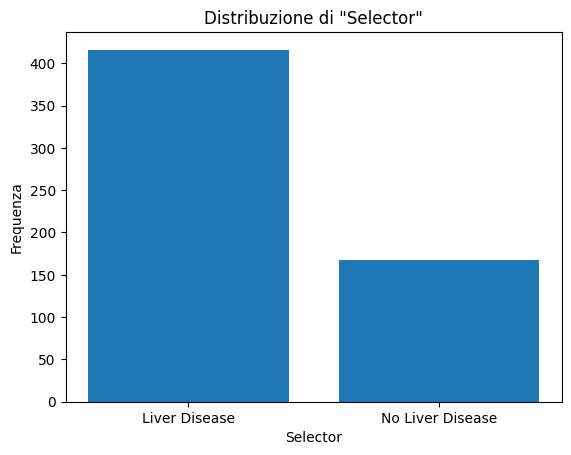

In [45]:
conteggi = df["Selector"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("Selector")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "Selector"')
plt.show()

### Creazione trainining e testing set

In [46]:
feature_names = set(df.columns) - set(["Selector"])

target_name = "Selector"

categorical_features = set(["Gender"])
continuos_features = feature_names - set(["Gender"])

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'Gender'}
{'DB', 'TP', 'Alkphos', 'Age', 'Sgot', 'TB', 'A/G Ratio', 'Sgpt', 'ALB'}


In [47]:
df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].astype("category").cat.codes
df_encoded["Selector"] = df_encoded["Selector"].astype("category").cat.codes

In [48]:
df_encoded

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,1
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,0
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,0
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,0


In [49]:
df_encoded["Selector"].dtype

dtype('int8')

In [50]:
df_encoded["Gender"].dtype

dtype('int8')

### addestriamo Il decisione Tree

In [51]:
y = df_encoded["Selector"]
#X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [52]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


In [53]:
X_train.head()

,Gender,DB,TP,ALB,Alkphos,Sgot,TB,A/G Ratio,Sgpt,Age
401,1,3.7,6.8,1.6,92,236,7.3,0.30,44,50
395,1,0.2,6.3,3.2,140,20,0.8,1.00,24,45
3,1,0.4,6.8,3.4,182,20,1.0,1.00,14,58
102,1,0.2,6.9,4.2,224,45,0.9,1.55,36,17
175,1,0.2,7.3,4.0,198,31,0.8,1.20,43,31


In [54]:
y_train.head()

401    0
395    1
3      0
102    0
175    0
Name: Selector, dtype: int8

In [55]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [56]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[92 33]
 [33 17]]

Accuracy: 0.6228571428571429


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74       125
           1       0.34      0.34      0.34        50

    accuracy                           0.62       175
   macro avg       0.54      0.54      0.54       175
weighted avg       0.62      0.62      0.62       175



### Miglioriamo l'albero

In [58]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [59]:
y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[104  21]
 [ 41   9]]

Accuracy: 0.6457142857142857


In [60]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       145
           1       0.18      0.30      0.23        30

    accuracy                           0.65       175
   macro avg       0.51      0.51      0.50       175
weighted avg       0.72      0.65      0.68       175



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [62]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00204248 0.00210084 0.00222816 0.00222816 0.00224673
 0.00226244 0.00239398 0.00245098 0.0025531  0.00313982 0.00326797
 0.00326797 0.00367647 0.00367647 0.00371361 0.00408497 0.00420168
 0.00421713 0.00425099 0.0043573  0.00441176 0.00441176 0.00446429
 0.0045098  0.00453893 0.00465686 0.00499076 0.00526823 0.00597672
 0.00640779 0.00661765 0.00670041 0.0070028  0.00719375 0.00784032
 0.00808945 0.00837527 0.00932351 0.01163107 0.01228434 0.0142603
 0.04182286]


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(4, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

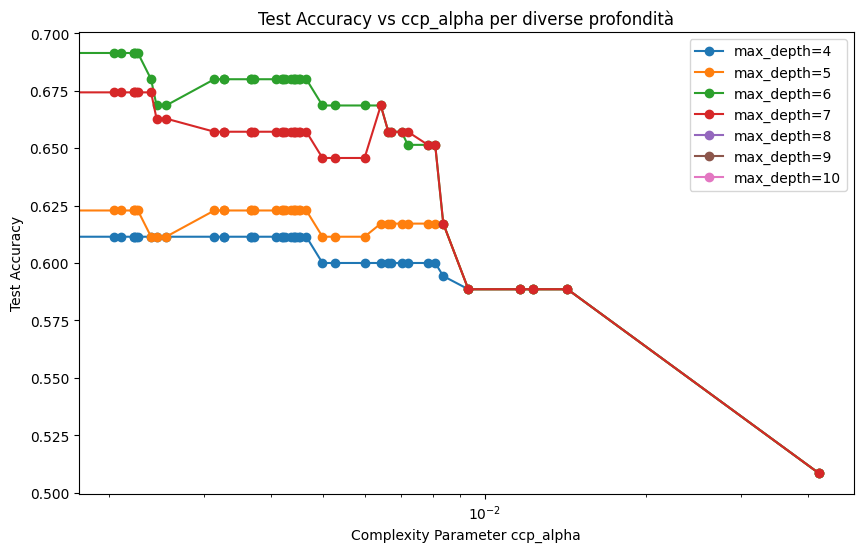

In [64]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["test_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [65]:
best_result = max(results, key=lambda x: x["test_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])

Miglior max_depth: 6
Miglior ccp_alpha: 0.0
Train accuracy: 0.7745098039215687
Test accuracy: 0.6914285714285714


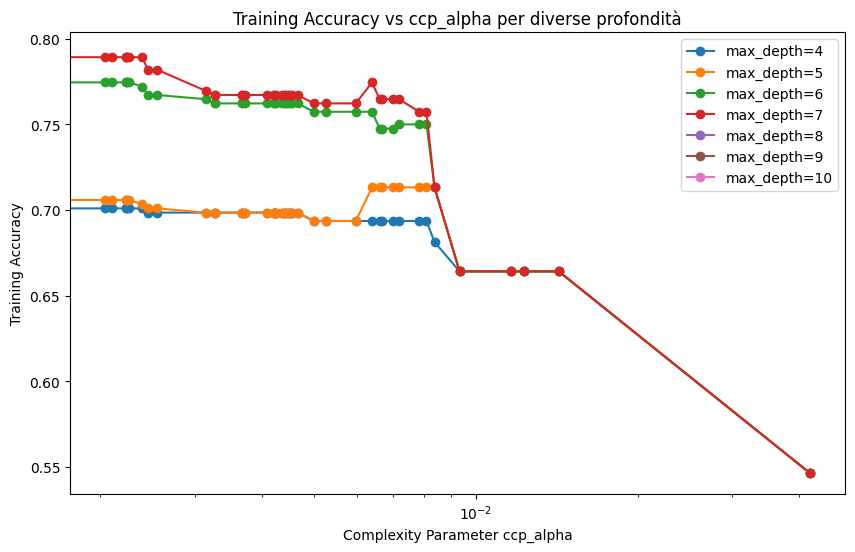

In [66]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [67]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 0.7745098039215687
Accuracy test: 0.6914285714285714


In [68]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[79 46]
 [ 8 42]]

Accuracy: 0.6914285714285714


In [69]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.63      0.91      0.75        87
           1       0.84      0.48      0.61        88

    accuracy                           0.69       175
   macro avg       0.74      0.69      0.68       175
weighted avg       0.74      0.69      0.68       175



### diamo un occhiata con la balancedPrecision

In [70]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.63      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.69       175
   macro avg       0.69      0.74      0.68       175
weighted avg       0.78      0.69      0.71       175

Balanced accuracy: 0.736
[[79 46]
 [ 8 42]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
            {0: 1, 1: 10}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [72]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 4.5},
    {0: 1, 1: 5},
    {0: 1, 1: 7},
    {0: 1, 1: 9},
    {0: 1, 1: 10}
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1"
)


Migliore configurazione trovata:
max_depth                             7
ccp_alpha                           0.0
class_weight               {0: 1, 1: 4}
weight_0                              1
weight_1                            4.0
train_accuracy                 0.776961
test_accuracy                  0.697143
train_balanced_accuracy        0.843643
test_balanced_accuracy             0.74
precision_class_1              0.482759
recall_class_1                     0.84
f1_class_1                     0.613139
macro_f1                       0.682156
weighted_f1                    0.711735
Name: 1424, dtype: object

Confusion matrix:
[[80 45]
 [ 8 42]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.64      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.70       175
   macro avg       0.70      0.74      0.68       175
weighted avg       0.79      0.70      0.71    

In [73]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.64      0.75       125
           1       0.48      0.84      0.61        50

    accuracy                           0.70       175
   macro avg       0.70      0.74      0.68       175
weighted avg       0.79      0.70      0.71       175



### Facciamo un ensemble a majority

In [74]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [75]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, part_index in splitter.split(X_train, y_train):
        X_part = X_train.iloc[part_index]
        y_part = y_train.iloc[part_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "accuracy": test_accuracy,
                    "balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [76]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]


#clean_training_results[] = best_models, results_df, best_row, best_predictions

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)
clean_training_results = best_models, results_df, best_row, best_predictions

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 5}, 'weight_0': 1, 'weight_1': 5, 'accuracy': 0.6057142857142858, 'balanced_accuracy': 0.706, 'precision_class_1': 0.415929203539823, 'recall_class_1': 0.94, 'f1_class_1': 0.5766871165644172, 'macro_f1': 0.603851579672583, 'weighted_f1': 0.6154934924332254}

Confusion matrix:
[[59 66]
 [ 3 47]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.47      0.63       125
           1       0.42      0.94      0.58        50

    accuracy                           0.61       175
   macro avg       0.68      0.71      0.60       175
weighted avg       0.80      0.61      0.62       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.5766871165644172


In [77]:
results_df.sort_values(
    by="f1_class_1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,accuracy,balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
454,5,0.004412,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
482,5,0.004539,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
496,5,0.004991,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
461,5,0.004412,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
349,5,0.002262,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
342,5,0.002247,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
328,5,0.002228,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
370,5,0.002553,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
377,5,0.003140,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493
363,5,0.002451,"{0: 1, 1: 5}",1,5.0,0.605714,0.706,0.415929,0.94,0.576687,0.603852,0.615493


In [78]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.47      0.63       125
           1       0.42      0.94      0.58        50

    accuracy                           0.61       175
   macro avg       0.68      0.71      0.60       175
weighted avg       0.80      0.61      0.62       175



### proviamo  a fare undersampling del dataframe

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split


def train_test_split_with_undersampling(
    df,
    target_col,
    test_size=0.3,
    random_state=42,
    stratify=False
):
    """
    Divide il DataFrame in train/test e applica undersampling solo al training set.

    Parametri:
    - df: DataFrame completo
    - target_col: nome della colonna target, esempio "Selector"
    - test_size: percentuale del test set
    - random_state: seed per riproducibilità
    - stratify: se True, mantiene proporzioni simili delle classi nello split

    Ritorna:
    - X_train_under
    - X_test
    - y_train_under
    - y_test
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    if stratify:
        stratify_values = y
    else:
        stratify_values = None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_values
    )

    train_df = X_train.copy()
    train_df[target_col] = y_train

    class_counts = train_df[target_col].value_counts()
    min_class_count = class_counts.min()

    undersampled_parts = []

    for class_value in class_counts.index:
        class_df = train_df[train_df[target_col] == class_value]

        class_df_under = class_df.sample(
            n=min_class_count,
            random_state=random_state
        )

        undersampled_parts.append(class_df_under)

    train_df_under = pd.concat(undersampled_parts)

    train_df_under = train_df_under.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X_train_under = train_df_under.drop(columns=[target_col])
    y_train_under = train_df_under[target_col]

    return X_train_under, X_test, y_train_under, y_test

In [80]:
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df=df_encoded,
    target_col="Selector",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [81]:
y_train.value_counts()

Selector
0    120
1    120
Name: count, dtype: int64

In [82]:
X_test.count()

Age          175
Gender       175
TB           175
DB           175
Alkphos      175
Sgpt         175
Sgot         175
TP           175
ALB          175
A/G Ratio    175
dtype: int64

In [83]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1.5}, 'weight_0': 1, 'weight_1': 1.5, 'accuracy': 0.6914285714285714, 'balanced_accuracy': 0.7755984042553192, 'precision_class_1': 0.4639175257731959, 'recall_class_1': 0.9574468085106383, 'f1_class_1': 0.625, 'macro_f1': 0.6814320388349515, 'weighted_f1': 0.7075520110957004}

Confusion matrix:
[[76 52]
 [ 2 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.625


In [84]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175



### Usiamo le random forests

In [85]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try,
    depths_to_try,
    weights_to_try,
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_model = None
    best_score = -1
    best_row = None
    best_predictions = None

    for n_estimators in n_estimators_to_try:
        for max_depth in depths_to_try:
            for weights in weights_to_try:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    class_weight=weights,
                    random_state=random_state,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                y_pred_train = rf.predict(X_train)
                y_pred_test = rf.predict(X_test)

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "class_weight": weights,
                    "weight_0": weights[0] if isinstance(weights, dict) else None,
                    "weight_1": weights[1] if isinstance(weights, dict) else None,

                    "train_accuracy": accuracy_score(y_train, y_pred_train),
                    "test_accuracy": accuracy_score(y_test, y_pred_test),
                    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),

                    "precision_class_1": precision_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "recall_class_1": recall_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "f1_class_1": f1_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        y_pred_test,
                        average="macro",
                        zero_division=0
                    )
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_model = rf
                    best_row = row
                    best_predictions = y_pred_test

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    return best_model, results_df, best_row, best_predictions

In [86]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

In [87]:
# best_rf.fit(X_train, y_train)

# y_pred_test = best_rf.predict(X_test)
# print(classification_report(y_test, y_pred_test, zero_division=0))

In [88]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

### Sporchiamo Il Dataset

In [89]:
# funzione per sporcare variabili categoriche
import numpy as np

import numpy as np







def corrupt_rows_cat(X_train, col, frac=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    # Generatore casuale riproducibile
    rng = np.random.default_rng(random_state)

    # Recupero i valori univoci della colonna
    unique_values = X_train_corrupt[col].unique()

    # Se esiste un solo valore, non posso sostituirlo con qualcosa di diverso
    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return X_train_corrupt

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    # Scelgo righe casuali senza ripetizione
    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Per ogni riga scelta, sostituisco il valore con un altro diverso
    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        pool_of_new_values = unique_values[unique_values != current_value]

        X_train_corrupt.at[idx, col] = rng.choice(pool_of_new_values)

    return X_train_corrupt


def corrupt_rows_cont(X_train, col, frac=0.1, noise_level=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    rng = np.random.default_rng(random_state)

    # Converto la colonna in float, così posso inserirci valori decimali
    X_train_corrupt[col] = X_train_corrupt[col].astype(float)

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    # Scelgo gli indici delle righe da corrompere
    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Deviazione standard della colonna
    std_col = X_train_corrupt[col].std()

    if std_col == 0:
        print(f"Attenzione: la colonna '{col}' ha deviazione standard 0. Nessuna modifica applicata.")
        return X_train_corrupt

    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        noise = rng.normal(
            loc=0,
            scale=noise_level * std_col
        )

        X_train_corrupt.at[idx, col] = current_value + noise

    return X_train_corrupt



### mostro le variabili dalla più importante alla meno importante

In [90]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# separo feature e target
X = df_encoded.drop(columns=["Selector"])
y = df_encoded["Selector"]

# scrivi qui le colonne categoriche
categoriche = ["Gender"]

# True per le categoriche, False per le continue
discrete_mask = []

for col in X.columns:
    if col in categoriche:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

# calcolo mutual information
mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

# creo tabella ordinata
importanza_variabili = pd.DataFrame({
    "variabile": X.columns,
    "importanza": mi
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza",
    ascending=False
)

print(importanza_variabili)

   variabile  importanza
0        Age    0.064974
6       Sgot    0.060338
2         TB    0.058162
5       Sgpt    0.056455
3         DB    0.051885
4    Alkphos    0.034634
8        ALB    0.030093
9  A/G Ratio    0.016904
1     Gender    0.003307
7         TP    0.000000


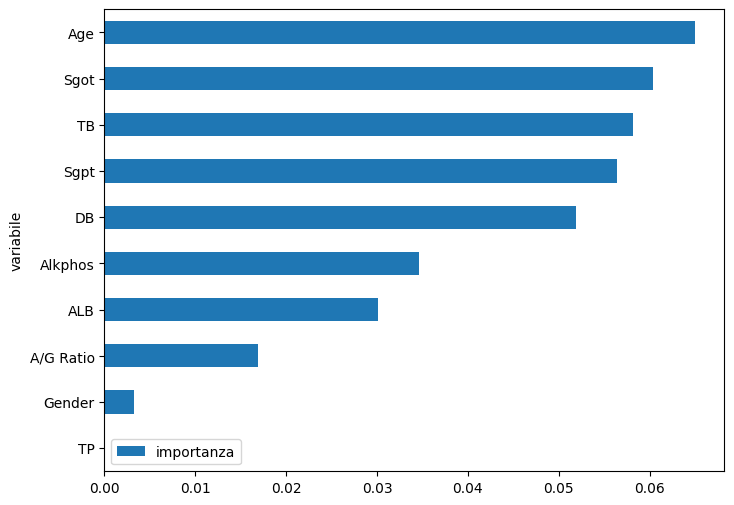

In [91]:
import matplotlib.pyplot as plt

importanza_variabili.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.show()

### Proviamo a sporcare la feature SGPT in maniera progressiva mentre lo addestriamo e vediamo di quanto cala la performance del modello

In [92]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


In [93]:
## AG ratio è continua, voglio quindi usare la funzione che sporca colonno continue
# una volta sporcata faccio partire un giro di training su ensemble
# dopo di che faccio una valutazione del modello e la confronto con il modello addestrato sul dataset non sporco

In [94]:
non_corrupted_data = [X_train, X_test, y_train, y_test]

In [95]:
#occhio, sto sovrascrivendo gli x_train e y_train puliti,non è un errore ma bisogna ricordarselo
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df_encoded,
    target_col="Selector",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [96]:
# df_corrotto = corrupt_rows_cont(
#     df_encoded,
#     col="Sgpt",
#     frac=0.2,
#     noise_level=0.1,
#     random_state=42
# )

In [97]:
noise_training_results = [] #best_models, results_df, best_row, best_predictions 

noise_training_results= search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.0), 'class_weight': {0: 1, 1: 1.5}, 'weight_0': 1, 'weight_1': 1.5, 'accuracy': 0.6914285714285714, 'balanced_accuracy': 0.7755984042553192, 'precision_class_1': 0.4639175257731959, 'recall_class_1': 0.9574468085106383, 'f1_class_1': 0.625, 'macro_f1': 0.6814320388349515, 'weighted_f1': 0.7075520110957004}

Confusion matrix:
[[76 52]
 [ 2 45]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.74       128
           1       0.46      0.96      0.62        47

    accuracy                           0.69       175
   macro avg       0.72      0.78      0.68       175
weighted avg       0.84      0.69      0.71       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.625


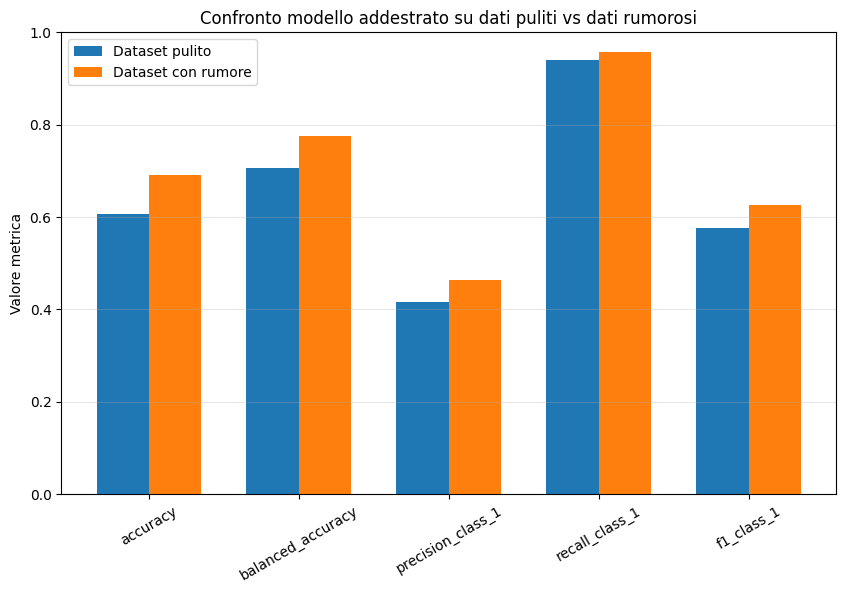

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Risultati modello pulito
clean_best_models, clean_results_df, clean_best_row, clean_best_predictions = clean_training_results

# Risultati modello con rumore
noise_best_models, noise_results_df, noise_best_row, noise_best_predictions = noise_training_results


# Funzione per trasformare best_row sempre in dizionario
def best_row_to_dict(best_row):
    if isinstance(best_row, pd.DataFrame):
        return best_row.iloc[0].to_dict()
    
    if isinstance(best_row, pd.Series):
        return best_row.to_dict()
    
    if isinstance(best_row, dict):
        return best_row
    
    raise TypeError("best_row deve essere un dict, una Series o un DataFrame")


clean_best_row = best_row_to_dict(clean_best_row)
noise_best_row = best_row_to_dict(noise_best_row)


# Metriche che voglio confrontare
possible_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1"
]

# Tengo solo le metriche presenti in entrambi
metrics = []

for metric in possible_metrics:
    if metric in clean_best_row.keys() and metric in noise_best_row.keys():
        metrics.append(metric)


# Valori delle metriche
clean_values = []

for metric in metrics:
    clean_values.append(clean_best_row[metric])


noise_values = []

for metric in metrics:
    noise_values.append(noise_best_row[metric])


# Grafico
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, clean_values, width, label="Dataset pulito")
plt.bar(x + width/2, noise_values, width, label="Dataset con rumore")

plt.xticks(x, metrics, rotation=30)
plt.ylabel("Valore metrica")
plt.title("Confronto modello addestrato su dati puliti vs dati rumorosi")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [99]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


In [100]:

# X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
#     df=df_encoded,
#     target_col="Gender",
#     test_size=0.7,
#     random_state=42,
#     stratify=False
# )



In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


def test_noise_progressivo(
    df,
    target_col,
    col_to_corrupt,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if col_to_corrupt == target_col:
        raise ValueError("Non devi sporcare la colonna target.")

    # ✔ SPLIT UNA SOLA VOLTA (FIX CRITICO)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    # identificazione tipo colonna
    is_categorical = (
        col_to_corrupt in categorical_cols or
        df[col_to_corrupt].dtype == "object" or
        str(df[col_to_corrupt].dtype) == "category" or
        df[col_to_corrupt].dtype == "bool" or
        (
            pd.api.types.is_integer_dtype(df[col_to_corrupt]) and
            df[col_to_corrupt].nunique() <= max_unique_for_cat
        )
    )

    print("Colonna riconosciuta come:",
          "categorica" if is_categorical else "continua")

    percentuali_rumore = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"Sto testando rumore al {int(frac*100)}%")

        # ✔ RESET TRAIN BASE OGNI ITERAZIONE
        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # ✔ CORRUZIONE
        if is_categorical:
            X_train = corrupt_rows_cat(
                X_train,
                col=col_to_corrupt,
                frac=frac,
                random_state=random_state
            )
        else:
            X_train = corrupt_rows_cont(
                X_train,
                col=col_to_corrupt,
                frac=frac,
                noise_level=noise_level,
                random_state=random_state
            )

        # ✔ TRAIN MODELLO
        training_results = search_best_ensemble_tree(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            ccp_alphas=ccp_alphas,
            weights_to_try=weights_to_try,
            depths=depths,
            scoring_metric=scoring_metric,
            random_state=random_state
        )

        best_models, results_df, best_row, best_predictions = training_results

        accuracy = accuracy_score(y_test, best_predictions)

        # normalizzazione output best_row
        if isinstance(best_row, pd.DataFrame):
            best_row_dict = best_row.iloc[0].to_dict()
        elif isinstance(best_row, pd.Series):
            best_row_dict = best_row.to_dict()
        elif isinstance(best_row, dict):
            best_row_dict = best_row.copy()
        else:
            raise TypeError("best_row formato non valido")

        best_row_dict.update({
            "accuracy": accuracy,
            "colonna_sporcata": col_to_corrupt,
            "tipo_colonna": "categorica" if is_categorical else "continua",
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_finali.append(best_row_dict)

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "best_models": best_models,
            "results_df": results_df,
            "best_row": best_row,
            "best_predictions": best_predictions,
            "accuracy": accuracy
        }

    risultati_df = pd.DataFrame(risultati_finali)

    metriche_possibili = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    metriche_presenti = [
        m for m in metriche_possibili if m in risultati_df.columns
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche_presenti:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale di righe corrotte")
    plt.ylabel("Valore metrica")
    plt.title(f"Prestazioni modello al crescere del rumore su {col_to_corrupt}")
    plt.ylim(0, 1)
    plt.xticks(risultati_df["percentuale_rumore"])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return risultati_df, risultati_completi

In [102]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0


Colonna riconosciuta come: continua
Sto testando rumore al 10%
Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.04182285659361773), 'class_weight': {0: 1, 1: 2}, 'weight_0': 1, 'weight_1': 2, 'accuracy': 0.6342857142857142, 'balanced_accuracy': 0.7298038563829787, 'precision_class_1': 0.41904761904761906, 'recall_class_1': 0.9361702127659575, 'f1_class_1': 0.5789473684210527, 'macro_f1': 0.6278575225943648, 'weighted_f1': 0.6504959368117263}

Confusion matrix:
[[67 61]
 [ 3 44]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.52      0.68       128
           1       0.42      0.94      0.58        47

    accuracy                           0.63       175
   macro avg       0.69      0.73      0.63       175
weighted avg       0.81      0.63      0.65       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.5789473684210527
Sto testando rumore al 20%
Migliore configurazione trovata:
{'

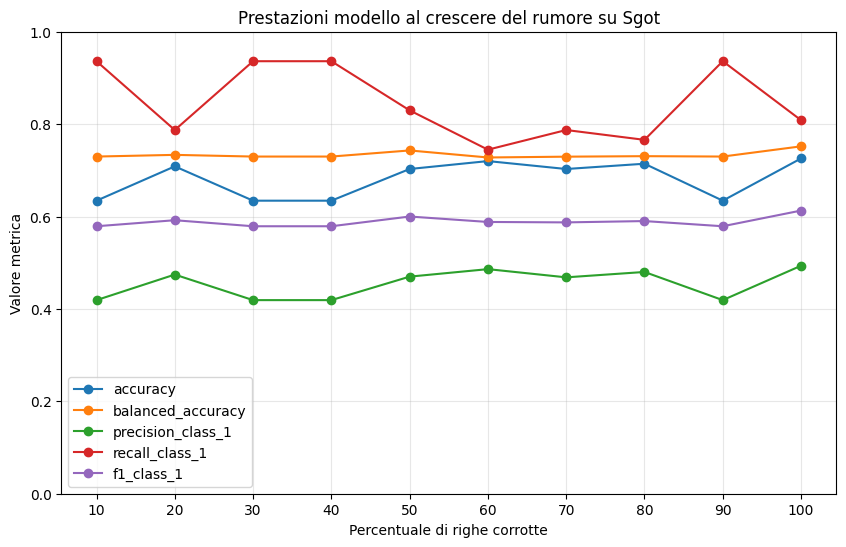

In [103]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="Selector",
    col_to_corrupt="Sgot",
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False
)


Colonna riconosciuta come: categorica
Sto testando rumore al 10%
Migliore configurazione trovata:
{'max_depth': 5, 'ccp_alpha': np.float64(0.014260304166229781), 'class_weight': {0: 1, 1: 2}, 'weight_0': 1, 'weight_1': 2, 'accuracy': 0.72, 'balanced_accuracy': 0.7412732712765957, 'precision_class_1': 0.4868421052631579, 'recall_class_1': 0.7872340425531915, 'f1_class_1': 0.6016260162601627, 'macro_f1': 0.6928834927115791, 'weighted_f1': 0.7351226675262347}

Confusion matrix:
[[89 39]
 [10 37]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.78       128
           1       0.49      0.79      0.60        47

    accuracy                           0.72       175
   macro avg       0.69      0.74      0.69       175
weighted avg       0.79      0.72      0.74       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.6016260162601627
Sto testando rumore al 20%
Migliore configurazione trovata:
{'max_depth': 

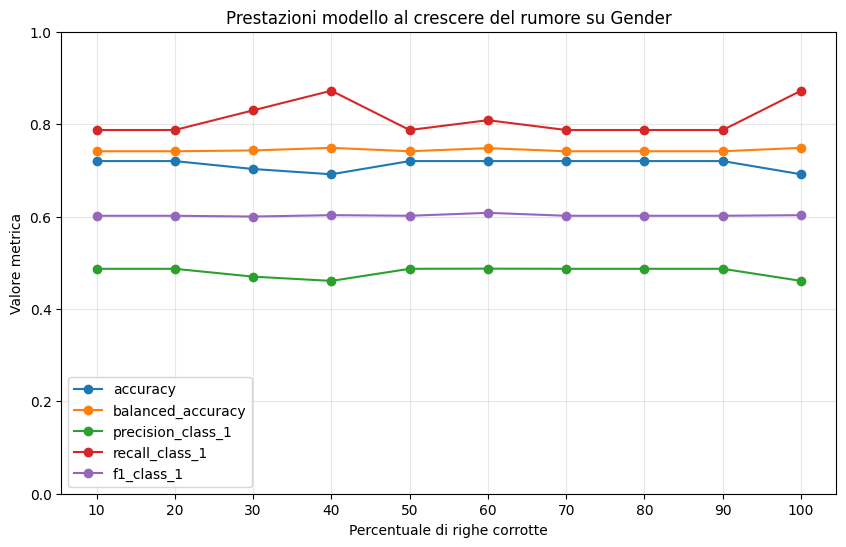

In [104]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="Selector",
    col_to_corrupt="Gender",
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False
)

Inizio rete neurale


In [105]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf


In [106]:
y = df_encoded["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [107]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [108]:
import numpy as np
from sklearn.metrics import confusion_matrix

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_pred = model.predict(X_test)

# conversione probabilità in classi
y_pred = (y_pred > 0.5).astype(int)



cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Confusion matrix:
 [[112  13]
 [ 40  10]]

Accuracy: 0.6971428571428572


In [109]:
def build_model_NN(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return model


def ensemble_predict_NN(models, X):
    preds = []

    for m in models:
        preds.append(m.predict(X, verbose=0))

    mean_pred = np.mean(preds, axis=0)
    return (mean_pred > 0.5).astype(int).flatten()



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def test_noise_progressivo_NN(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non puoi sporcare il target")

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    print("Colonne da corrompere:")
    for k, v in tipo_colonne.items():
        print(f" - {k}: {'categorica' if v else 'continua'}")

    #  SPLIT UNICO
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # ✔ CORRUZIONE
        for col in cols_to_corrupt:

            if tipo_colonne[col]:
                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=random_state
                )
            else:
                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=random_state
                )

        models = []

        #  ENSEMBLE CON BOOTSTRAP
        for i in range(3):

            tf.random.set_seed(random_state + i)

            idx = np.random.choice(len(X_train), len(X_train), replace=True)

            X_boot = X_train.iloc[idx]
            y_boot = y_train.iloc[idx]

            model = tf.keras.Sequential([
                tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
                tf.keras.layers.Dense(16, activation="relu"),
                tf.keras.layers.Dense(1, activation="sigmoid")
            ])

            model.compile(
                optimizer="adam",
                loss="binary_crossentropy"
            )

            model.fit(
                X_boot,
                y_boot,
                epochs=30,
                batch_size=32,
                verbose=0
            )

            models.append(model)

        #  PREDIZIONE ENSEMBLE
        preds = []

        for m in models:
            preds.append(m.predict(X_test, verbose=0))

        mean_pred = np.mean(preds, axis=0)
        y_pred = (mean_pred > 0.5).astype(int).flatten()

        #  METRICHE
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        risultati_finali.append({
            "accuracy": accuracy,
            "f1_class_1": f1,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "balanced_accuracy": balanced_acc,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "models": models,
            "y_pred": y_pred
        }

    risultati_df = pd.DataFrame(risultati_finali)

    #  GRAFICO
    metriche = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza NN ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)

    return risultati_df, risultati_completi

Colonne da corrompere:
 - Sgot: continua
 - Age: continua
 - TB: continua
 - DB: continua
 - Sgpt: continua

Rumore: 0%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 10%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 20%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 30%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 40%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 50%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 60%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 70%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 80%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


Rumore: 90%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Rumore: 100%


c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer

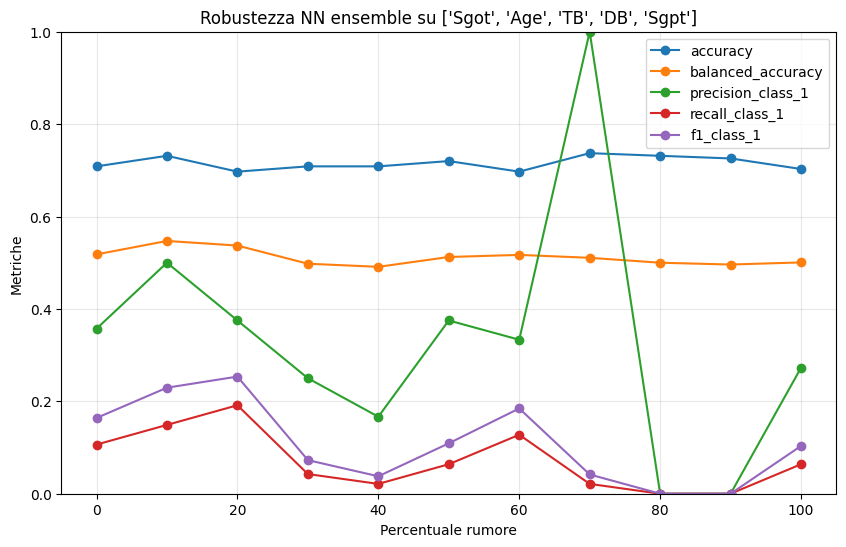

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.708571    0.163934           0.357143        0.106383   
1   0.731429    0.229508           0.500000        0.148936   
2   0.697143    0.253521           0.375000        0.191489   
3   0.708571    0.072727           0.250000        0.042553   
4   0.708571    0.037736           0.166667        0.021277   
5   0.720000    0.109091           0.375000        0.063830   
6   0.697143    0.184615           0.333333        0.127660   
7   0.737143    0.041667           1.000000        0.021277   
8   0.731429    0.000000           0.000000        0.000000   
9   0.725714    0.000000           0.000000        0.000000   
10  0.702857    0.103448           0.272727        0.063830   

    balanced_accuracy     colonne_sporcate  frac_rumore  percentuale_rumore  
0            0.518035  Sgot,Age,TB,DB,Sgpt          0.0                   0  
1            0.547124  Sgot,Age,TB,DB,Sgpt          0.1                  10  
2        

In [110]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=["Sgot", "Age", "TB", "DB", "Sgpt"],
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    stratify=False,
)

Inizio svg

In [111]:
y = df_encoded["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [112]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [113]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Creazione del modello SVM
model = SVC(
    kernel="rbf",        
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

# Addestramento
model.fit(X_train, y_train)

# Predizioni
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

Confusion matrix:
 [[57 68]
 [ 4 46]]

Accuracy: 0.5885714285714285


In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_SVM():
    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )
    return model


def ensemble_predict_SVM(models, X):

    preds = []

    for m in models:
        preds.append(m.predict(X))

    preds = np.array(preds)

    # Majority voting
    y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

    return y_pred




def test_noise_progressivo_SVM(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non puoi sporcare il target")

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    print("Colonne da corrompere:")
    for k, v in tipo_colonne.items():
        print(f" - {k}: {'categorica' if v else 'continua'}")

    # SPLIT UNA SOLA VOLTA (FIX come NN)
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # CORRUZIONE
        for col in cols_to_corrupt:

            if tipo_colonne[col]:
                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=random_state
                )
            else:
                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=random_state
                )

        models = []

        # ENSEMBLE CON BOOTSTRAP (FIX come NN)
        for i in range(3):

            idx = np.random.choice(len(X_train), len(X_train), replace=True)

            X_boot = X_train.iloc[idx]
            y_boot = y_train.iloc[idx]

            model = SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced"
            )

            model.fit(X_boot, y_boot)

            models.append(model)

        # PREDIZIONE ENSEMBLE (majority vote coerente)
        preds = []

        for m in models:
            preds.append(m.predict(X_test))

        preds = np.array(preds)

        y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

        # METRICHE
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        risultati_finali.append({
            "accuracy": accuracy,
            "f1_class_1": f1,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "balanced_accuracy": balanced_acc,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "models": models,
            "y_pred": y_pred
        }

    risultati_df = pd.DataFrame(risultati_finali)

    # GRAFICO IDENTICO NN
    metriche = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza SVM ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)

    return risultati_df, risultati_completi

Colonne da corrompere:
 - Sgot: continua
 - Age: continua
 - TB: continua
 - DB: continua
 - Sgpt: continua

Rumore: 0%

Rumore: 10%

Rumore: 20%

Rumore: 30%

Rumore: 40%

Rumore: 50%

Rumore: 60%

Rumore: 70%

Rumore: 80%

Rumore: 90%

Rumore: 100%


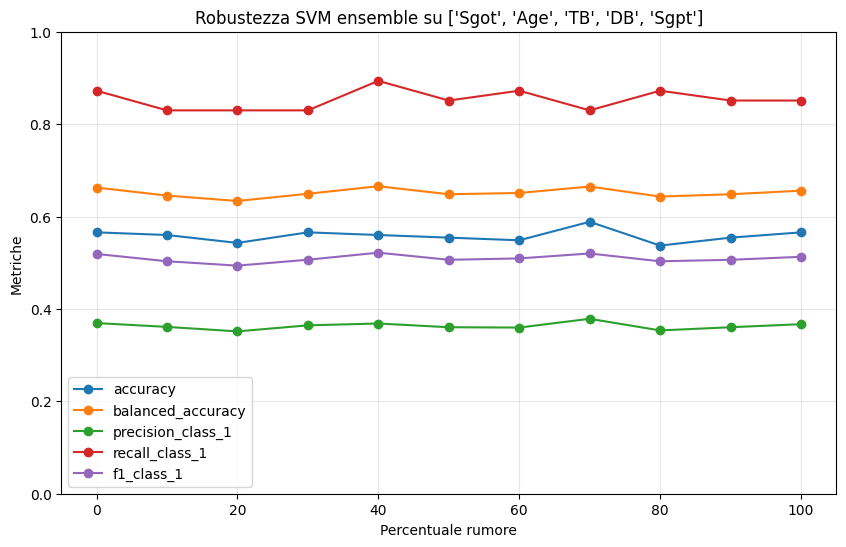

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.565714    0.518987           0.369369        0.872340   
1   0.560000    0.503226           0.361111        0.829787   
2   0.542857    0.493671           0.351351        0.829787   
3   0.565714    0.506494           0.364486        0.829787   
4   0.560000    0.521739           0.368421        0.893617   
5   0.554286    0.506329           0.360360        0.851064   
6   0.548571    0.509317           0.359649        0.872340   
7   0.588571    0.520000           0.378641        0.829787   
8   0.537143    0.503067           0.353448        0.872340   
9   0.554286    0.506329           0.360360        0.851064   
10  0.565714    0.512821           0.366972        0.851064   

    balanced_accuracy     colonne_sporcate  frac_rumore  percentuale_rumore  
0            0.662733  Sgot,Age,TB,DB,Sgpt          0.0                   0  
1            0.645362  Sgot,Age,TB,DB,Sgpt          0.1                  10  
2        

In [115]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=["Sgot", "Age", "TB", "DB", "Sgpt"],
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    stratify=False,
)